# Results analysis: reproductions and the G1 preview

Reads `results/runs.jsonl` (every finished run) and `results/reproduction/published.csv` (the papers' numbers),
and draws the comparison figures. The notebook is read-only: it never runs an experiment and never writes into
`results/`. Figures are saved as PNG to `notebooks/figures/`.

Run from `code/`: `uv run jupyter lab notebooks/analysis.ipynb`, or open it in VS Code. Per-round curves need the
run folders (`runs/`, and Colab runs copied to `runs/colab/`); those sections are skipped when the folders are missing.

In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Works whether the kernel starts in code/ or code/notebooks/.
CODE_DIR = Path.cwd() if (Path.cwd() / "src" / "fairfl").exists() else Path.cwd().parent
RESULTS = CODE_DIR / "results"
RUNS = CODE_DIR / "runs"
FIGURES = CODE_DIR / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper")
STATUS_COLOURS = {"OK": "#55a868", "GAP": "#c44e52", "NOT RUN": "#b0b0b0"}
SOURCE_COLOURS = {"paper": "#8c8c8c", "ours": "#4c72b0"}


def save_fig(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=200, bbox_inches="tight")
    print(f"saved figures/{name}.png")


def latest_runs():
    runs = {}
    for line in (RESULTS / "runs.jsonl").read_text(encoding="utf-8").splitlines():
        if line.strip():
            row = json.loads(line)
            runs[row["name"]] = row  # later lines win
    return runs


def comparison(rel_tol=0.02, abs_tol=0.01):
    # Same rule as fairfl.experiments.compare, without writing the CSV (this notebook is read-only).
    runs = latest_runs()
    pub = pd.read_csv(RESULTS / "reproduction" / "published.csv")
    rows = []
    for p in pub.itertuples():
        run = runs.get(p.run_name)
        v = run["summary"].get(p.our_field) if run else None
        ours = None if v is None else float(v) * float(p.scale)
        if ours is None:
            status = "NOT RUN"
        else:
            slack = abs_tol * p.scale if p.scale <= 100 else 0.0
            status = "OK" if abs(ours - p.published) <= max(slack, rel_tol * abs(p.published)) else "GAP"
        rows.append({"paper": p.paper, "setting": p.setting, "run": p.run_name, "metric": p.metric,
                     "paper_value": p.published, "ours": ours, "status": status})
    return pd.DataFrame(rows)


cmp = comparison()
cmp.groupby(["paper", "status"]).size().unstack(fill_value=0)

status,GAP,NOT RUN,OK
paper,,,
FCFL,8,0,3
FairRFL,0,88,0
FairWeight,18,0,6
FedCDA,0,24,0
FedFDP,0,3,0
FedMut,4,12,0
LoGoFair,14,0,22


## 1. Reproduction status per paper

How many of each paper's published values we have matched (within 2% relative, or 0.01 / 1 point absolute for
rates), missed, or not run yet. Median (Chen et al.) is checked separately in section 5.

saved figures/repro_status.png


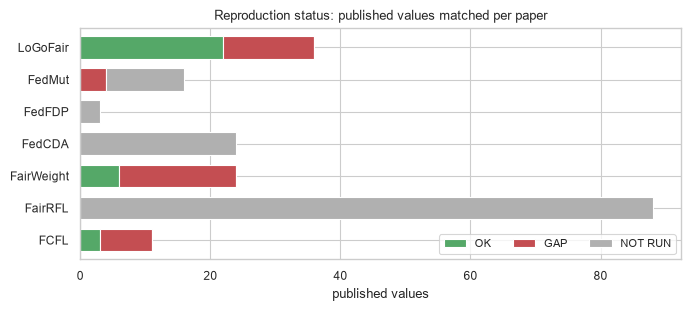

In [2]:
counts = cmp.groupby(["paper", "status"]).size().unstack(fill_value=0).reindex(columns=list(STATUS_COLOURS),
                                                                                fill_value=0)
fig, ax = plt.subplots(figsize=(7, 3.2))
counts.plot(kind="barh", stacked=True, color=[STATUS_COLOURS[c] for c in counts.columns], ax=ax, width=0.7)
ax.set_xlabel("published values")
ax.set_ylabel("")
ax.legend(title=None, ncol=3, loc="lower right", fontsize=8)
ax.set_title("Reproduction status: published values matched per paper")
plt.tight_layout()
save_fig(fig, "repro_status")
plt.show()

## 2. Paper vs ours, per paper

One panel per metric (metrics live on different scales); grey = published, blue = ours.

saved figures/fcfl_paper_vs_ours.png


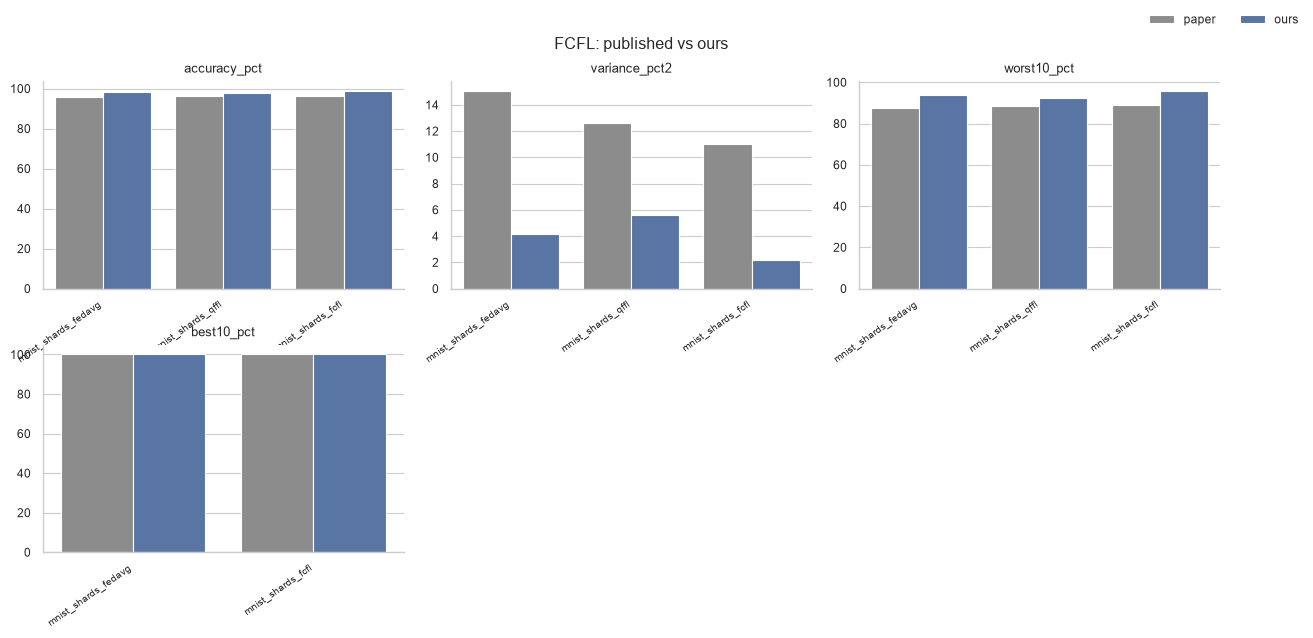

In [3]:
def paper_vs_ours(paper, name, runs=None, col_wrap=3):
    d = cmp[(cmp.paper == paper) & cmp.ours.notna()]
    if runs:
        d = d[d.run.isin(runs)]
    if d.empty:
        print(f"{paper}: nothing run yet")
        return
    d = d.assign(label=d.run.str.replace(r"^[a-z]+_", "", regex=True))
    long = d.melt(id_vars=["label", "metric"], value_vars=["paper_value", "ours"], var_name="source")
    long["source"] = long["source"].replace({"paper_value": "paper"})
    g = sns.catplot(data=long, kind="bar", x="label", y="value", hue="source", col="metric", col_wrap=col_wrap,
                    sharey=False, sharex=False, palette=SOURCE_COLOURS, height=2.8, aspect=1.5)
    sns.move_legend(g, "upper right", bbox_to_anchor=(1.0, 1.08), ncol=2, title=None)
    g.set_titles("{col_name}")
    g.set_axis_labels("", "")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=35, labelsize=7)
        for lbl in ax.get_xticklabels():
            lbl.set_horizontalalignment("right")
    g.figure.suptitle(f"{paper}: published vs ours", y=1.02)
    save_fig(g.figure, name)
    plt.show()


paper_vs_ours("FCFL", "fcfl_paper_vs_ours")

saved figures/logofair_paper_vs_ours.png


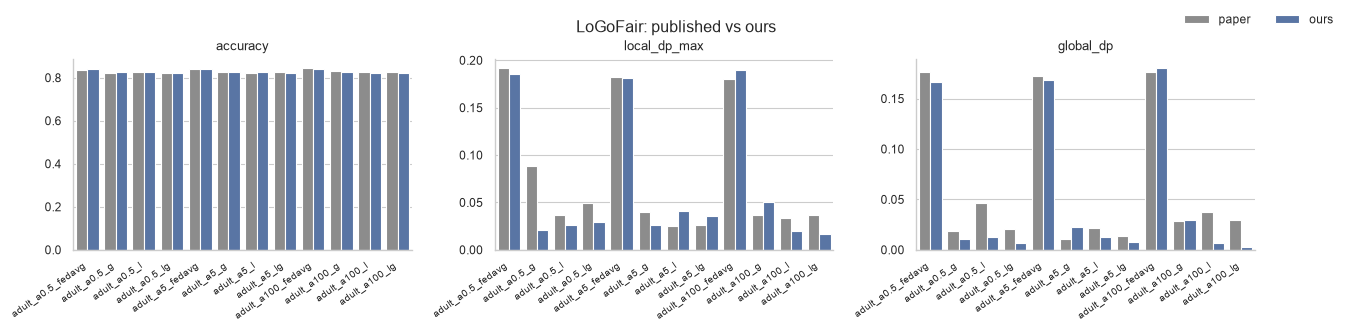

In [4]:
paper_vs_ours("LoGoFair", "logofair_paper_vs_ours")

saved figures/fairweight_paper_vs_ours.png


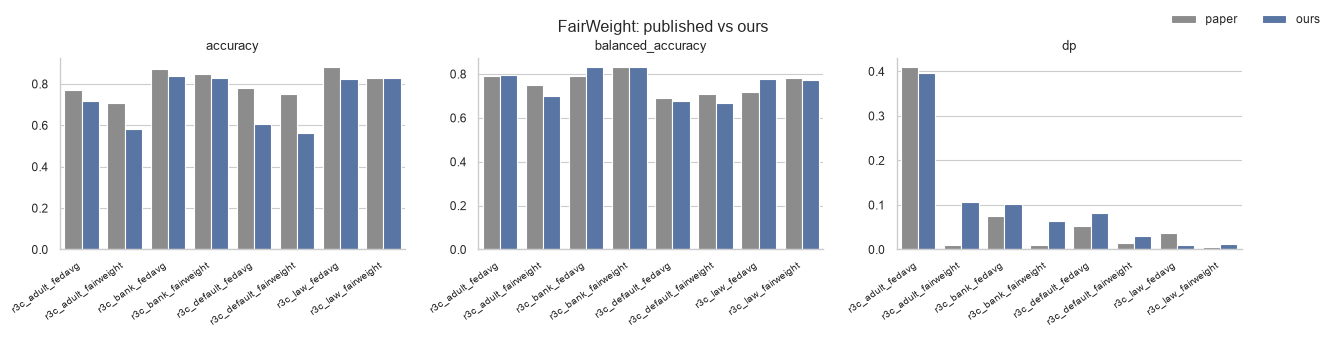

In [5]:
paper_vs_ours("FairWeight", "fairweight_paper_vs_ours", col_wrap=3)

saved figures/fedmut_paper_vs_ours.png


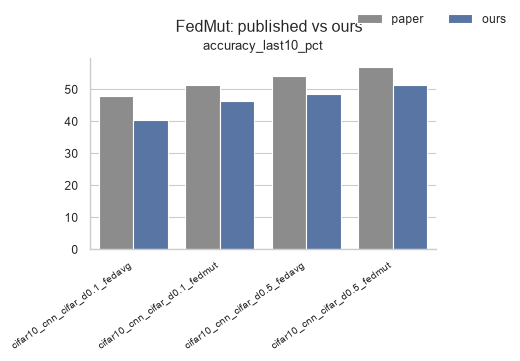

In [6]:
paper_vs_ours("FedMut", "fedmut_paper_vs_ours", col_wrap=1)

In [7]:
for p in ("FedCDA", "FedFDP", "FairRFL"):
    paper_vs_ours(p, f"{p.lower()}_paper_vs_ours")

FedCDA: nothing run yet
FedFDP: nothing run yet
FairRFL: nothing run yet


## 3. How far off are we? Relative difference for every value run so far

(ours - paper) / |paper|. Points inside the shaded band count as a match. Fairness gaps close to zero (e.g. DP of
0.005) make relative differences look large, so read this together with section 4.

saved figures/repro_relative_diff.png


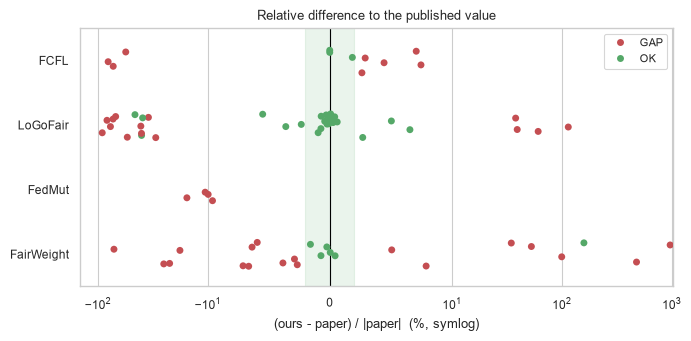

In [8]:
d = cmp[cmp.ours.notna()].copy()
d["rel_diff_pct"] = 100 * (d.ours - d.paper_value) / d.paper_value.abs()
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.stripplot(data=d, y="paper", x="rel_diff_pct", hue="status", palette=STATUS_COLOURS, size=5, jitter=0.2, ax=ax)
ax.axvspan(-2, 2, color="#55a868", alpha=0.12)
ax.axvline(0, color="black", lw=0.8)
ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel("(ours - paper) / |paper|  (%, symlog)")
ax.set_ylabel("")
ax.legend(title=None, fontsize=8)
ax.set_title("Relative difference to the published value")
plt.tight_layout()
save_fig(fig, "repro_relative_diff")
plt.show()

## 4. Do the papers' claims hold? Method vs its baseline, paper vs ours

A reproduction can miss absolute numbers and still confirm the claim. Each bar is the change the method makes
relative to its baseline (FedAvg), in the direction the paper claims is better (positive = the method helps).

In [9]:
# (label, baseline run, method run, metric, +1 if higher is better / -1 if lower is better)
CLAIMS = [
    ("FCFL: variance", "fcfl_mnist_shards_fedavg", "fcfl_mnist_shards_fcfl", "variance_pct2", -1),
    ("FCFL: worst 10%", "fcfl_mnist_shards_fedavg", "fcfl_mnist_shards_fcfl", "worst10_pct", +1),
] + [
    (f"LoGoFair a={a}: global DP", f"logofair_adult_a{a}_fedavg", f"logofair_adult_a{a}_lg", "global_dp", -1)
    for a in ("0.5", "5", "100")
] + [
    (f"FairWeight {ds}: DP", f"fairweight_r3c_{ds}_fedavg", f"fairweight_r3c_{ds}_fairweight", "dp", -1)
    for ds in ("adult", "bank", "default", "law")
] + [
    (f"FedMut {s}: accuracy", f"fedmut_cifar10_cnn_cifar_{s}_fedavg", f"fedmut_cifar10_cnn_cifar_{s}_fedmut",
     "accuracy_last10_pct", +1)
    for s in ("d0.1", "d0.5", "d1.0", "iid")
]

idx = cmp.drop_duplicates(["run", "metric"], keep="last").set_index(["run", "metric"])
rows = []
for label, base, meth, metric, sign in CLAIMS:
    try:
        b, m = idx.loc[(base, metric)], idx.loc[(meth, metric)]
    except KeyError:
        continue
    paper_gain = sign * (m.paper_value - b.paper_value)
    ours_gain = sign * (m.ours - b.ours) if pd.notna(m.ours) and pd.notna(b.ours) else np.nan
    rows.append({"claim": label, "paper": paper_gain, "ours": ours_gain,
                 "paper_rel": paper_gain / abs(b.paper_value), "ours_rel": ours_gain / abs(b.ours) if b.ours else np.nan})
claims = pd.DataFrame(rows).dropna(subset=["ours"])
claims["verdict"] = np.where(claims.ours > 0, "claim holds", "claim fails")
claims.round(4)

,claim,paper,ours,paper_rel,ours_rel,verdict
0,FCFL: variance,4.0300,2.0081,0.2676,0.4819,claim holds
1,FCFL: worst 10%,1.7000,2.1667,0.0194,0.0231,claim holds
2,LoGoFair a=0.5: global DP,0.1555,0.1599,0.8840,0.9616,claim holds
3,LoGoFair a=5: global DP,0.1587,0.1610,0.9200,0.9556,claim holds
4,LoGoFair a=100: global DP,0.1462,0.1780,0.8312,0.9853,claim holds
5,FairWeight adult: DP,0.3990,0.2902,0.9756,0.7306,claim holds
6,FairWeight bank: DP,0.0650,0.0387,0.8553,0.3777,claim holds
7,FairWeight default: DP,0.0380,0.0511,0.7170,0.6299,claim holds
8,FairWeight law: DP,0.0320,-0.0023,0.8649,-0.2164,claim fails
9,FedMut d0.1: accuracy,3.3200,5.8000,0.0693,0.1431,claim holds


saved figures/repro_claims.png


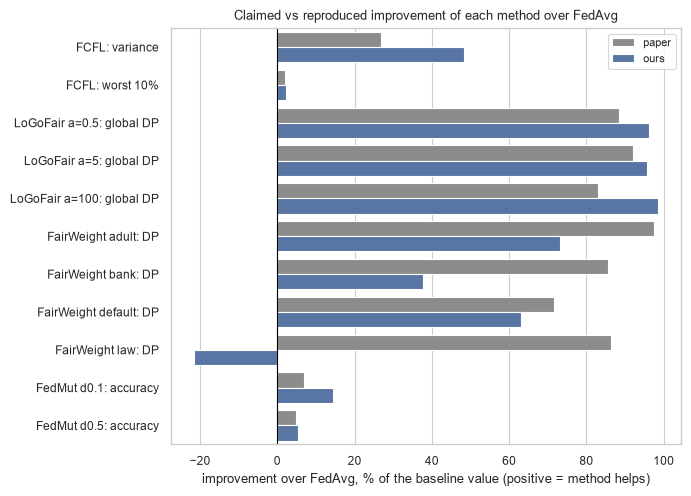

In [10]:
if len(claims):
    long = claims.melt(id_vars="claim", value_vars=["paper_rel", "ours_rel"], var_name="source", value_name="gain")
    long["source"] = long["source"].str.replace("_rel", "")
    long["gain"] *= 100
    fig, ax = plt.subplots(figsize=(7, 0.35 * len(claims) + 1.2))
    sns.barplot(data=long, y="claim", x="gain", hue="source", palette=SOURCE_COLOURS, ax=ax)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("improvement over FedAvg, % of the baseline value (positive = method helps)")
    ax.set_ylabel("")
    ax.legend(title=None, fontsize=8)
    ax.set_title("Claimed vs reproduced improvement of each method over FedAvg")
    plt.tight_layout()
    save_fig(fig, "repro_claims")
    plt.show()

## 5. Median (Chen et al., NeurIPS 2020) Fig. 1 toy example

Three nodes with f_i(x) = (x - a_i)^2 / 2, a = (1, 2, 10). The true optimum (mean) is x = 13/3; median and
signSGD stall at the median a_2 = 2, and adding noise before the median moves it towards the mean.

saved figures/median_toy.png


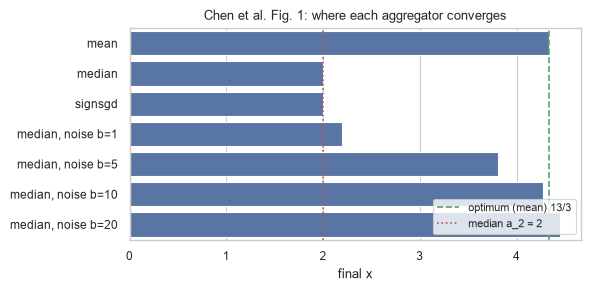

,label,x,mean_grad,median_grad
0,mean,4.3331,-0.0002,2.3331
1,median,1.9999,-2.3334,-0.0001
2,signsgd,2.0005,-2.3328,0.0005
3,"median, noise b=1",2.1979,-2.1355,0.1979
4,"median, noise b=5",3.8063,-0.5271,1.8063
5,"median, noise b=10",4.2693,-0.0641,2.2693
6,"median, noise b=20",4.4460,0.1126,2.4460


In [11]:
toy = pd.DataFrame([json.loads(l) for l in (RESULTS / "reproduction" / "median_toy.jsonl").read_text().splitlines() if l.strip()])
toy["label"] = toy.apply(lambda r: r.method if r.b == 0 else f"{r.method}, noise b={r.b:g}", axis=1)
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(data=toy, y="label", x="x", color="#4c72b0", ax=ax)
ax.axvline(13 / 3, color="#55a868", ls="--", label="optimum (mean) 13/3")
ax.axvline(2, color="#c44e52", ls=":", label="median a_2 = 2")
ax.set_xlabel("final x")
ax.set_ylabel("")
ax.legend(fontsize=8, loc="lower right")
ax.set_title("Chen et al. Fig. 1: where each aggregator converges")
plt.tight_layout()
save_fig(fig, "median_toy")
plt.show()
toy[["label", "x", "mean_grad", "median_grad"]].round(4)

## 6. Training curves

Global test accuracy over rounds for every run folder that has a `rounds.jsonl` (local `runs/` and Colab runs
copied to `runs/colab/`).

saved figures/fedmut_curves.png


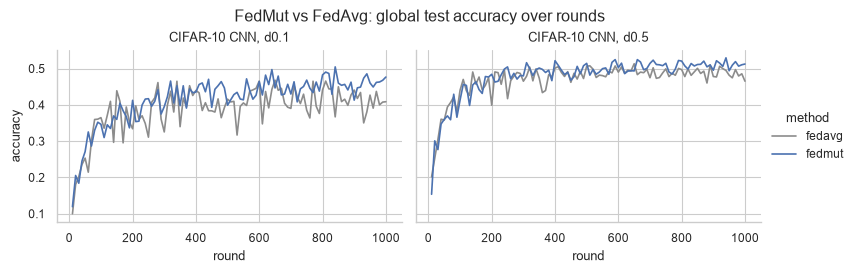

In [12]:
def load_curve(path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        r = json.loads(line)
        gt = r.get("global_test") or {}
        rows.append({"round": r["round"] + 1, "accuracy": gt.get("accuracy", r.get("global_accuracy")),
                     "loss": gt.get("loss", r.get("global_loss"))})
    return pd.DataFrame(rows)


colab = sorted((RUNS / "colab").glob("fedmut_*/seed*/rounds.jsonl")) if (RUNS / "colab").exists() else []
if not colab:
    print("No Colab FedMut run folders in runs/colab/ yet.")
else:
    curves = pd.concat([load_curve(p).assign(run=p.parent.parent.name) for p in colab])
    curves["setting"] = curves.run.str.extract(r"cifar_(d[0-9.]+|iid)_")[0]
    curves["method"] = curves.run.str.extract(r"_(fedavg|fedmut)$")[0]
    g = sns.relplot(data=curves, kind="line", x="round", y="accuracy", hue="method", col="setting", col_wrap=2,
                    height=2.6, aspect=1.5, palette={"fedavg": "#8c8c8c", "fedmut": "#4c72b0"})
    g.set_titles("CIFAR-10 CNN, {col_name}")
    g.figure.suptitle("FedMut vs FedAvg: global test accuracy over rounds", y=1.03)
    save_fig(g.figure, "fedmut_curves")
    plt.show()

## 7. G1 preview: does final-round reporting hide unfairness during training?

FedMut d = 0.1 runs only (clients hold no test data there). Two stand-ins for groups:
- per-class accuracy on the global test set (classes as groups);
- per-client *experienced* accuracy = per-class accuracy weighted by each client's class mix in the shipped
  partition.

The same model is judged three ways: at the final round, over the last 10 evaluations, and averaged over the whole
of training (what users of intermediate models actually got).

saved figures/g1_preview_curves.png


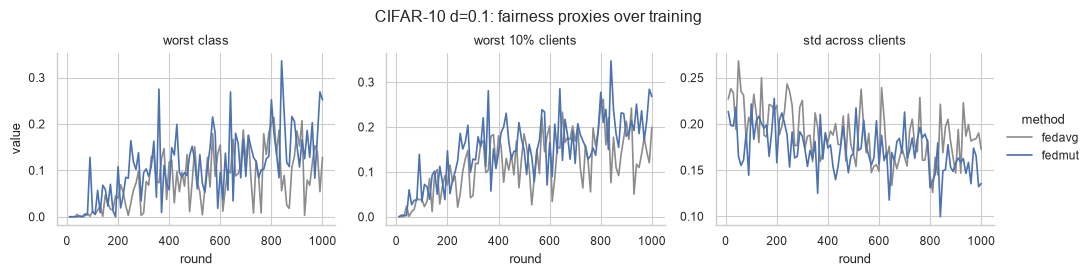

In [13]:
def g1_frame(run_dir, mix):
    rows = []
    for line in (run_dir / "rounds.jsonl").read_text(encoding="utf-8").splitlines():
        r = json.loads(line)
        g = r["global_test"]["groups"]
        cls = np.array(g["correct"][0]) / np.array(g["n"][0])
        client = mix @ cls
        rows.append({"round": r["round"] + 1, "accuracy": r["global_test"]["accuracy"],
                     "worst class": cls.min(), "worst 10% clients": np.sort(client)[:10].mean(),
                     "std across clients": client.std()})
    return pd.DataFrame(rows)


cifar = CODE_DIR / "data" / "cifar-10-batches-py"
runs_g1 = {m: RUNS / "colab" / f"fedmut_cifar10_cnn_cifar_d0.1_{m}" / "seed0" for m in ("fedavg", "fedmut")}
if not cifar.exists() or not all((d / "rounds.jsonl").exists() for d in runs_g1.values()):
    print("Needs data/cifar-10-batches-py and the two d0.1 run folders in runs/colab/.")
    g1 = None
else:
    labels = np.concatenate([pickle.load(open(cifar / f"data_batch_{i}", "rb"), encoding="latin1")["labels"]
                             for i in range(1, 6)])
    part = json.load(open(CODE_DIR / "assets/partitions/fedmut/cifar10_100_noniidCase5_beta0.1.json"))["train_data"]
    mix = np.array([np.bincount(labels[np.array(part[str(c)], int)], minlength=10) for c in range(100)], float)
    mix /= mix.sum(1, keepdims=True)
    g1 = pd.concat([g1_frame(d, mix).assign(method=m) for m, d in runs_g1.items()])

    metrics = ["worst class", "worst 10% clients", "std across clients"]
    long = g1.melt(id_vars=["round", "method"], value_vars=metrics, var_name="metric")
    g = sns.relplot(data=long, kind="line", x="round", y="value", hue="method", col="metric",
                    facet_kws={"sharey": False}, height=2.6, aspect=1.3,
                    palette={"fedavg": "#8c8c8c", "fedmut": "#4c72b0"})
    g.set_titles("{col_name}")
    g.figure.suptitle("CIFAR-10 d=0.1: fairness proxies over training", y=1.04)
    save_fig(g.figure, "g1_preview_curves")
    plt.show()

saved figures/g1_preview_scopes.png


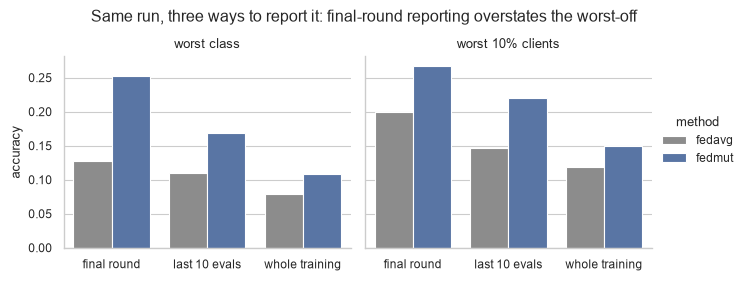

,evals with a class below 5% accuracy,evals
method,,
fedavg,35,100
fedmut,22,100


In [14]:
if g1 is not None:
    rows = []
    for m, d in g1.groupby("method"):
        for metric in ["worst class", "worst 10% clients"]:
            v = d[metric].to_numpy()
            rows += [{"method": m, "metric": metric, "scope": "final round", "value": v[-1]},
                     {"method": m, "metric": metric, "scope": "last 10 evals", "value": v[-10:].mean()},
                     {"method": m, "metric": metric, "scope": "whole training", "value": v.mean()}]
    scopes = pd.DataFrame(rows)
    g = sns.catplot(data=scopes, kind="bar", x="scope", y="value", hue="method", col="metric", height=2.8,
                    aspect=1.2, palette={"fedavg": "#8c8c8c", "fedmut": "#4c72b0"})
    g.set_titles("{col_name}")
    g.set_axis_labels("", "accuracy")
    g.figure.suptitle("Same run, three ways to report it: final-round reporting overstates the worst-off", y=1.05)
    save_fig(g.figure, "g1_preview_scopes")
    plt.show()
    near_zero = g1.assign(bad=g1["worst class"] < 0.05).groupby("method")["bad"].agg(["sum", "count"])
    near_zero.columns = ["evals with a class below 5% accuracy", "evals"]
    display(near_zero)